## Prediction Model - E-Commerce Reviews

#### Goal:
Build a binary prediction workflow to classify whether a review is good or bad using the latest engineered dataset.

In [181]:
# Import modeling, plotting, preprocessing, and evaluation dependencies.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from catboost import CatBoostClassifier



In [182]:
# Resolve project paths and load the latest denormalized dataset for modeling.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
src_path = project_root / 'src'

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from data_cleaning_tools import denormalize_olist_datasets

datasets_path = project_root / 'datasets'
df_raw_data = denormalize_olist_datasets(datasets_dir=datasets_path, drop_nulls=True)
df_raw_data.shape

(11112, 49)

In [183]:
# Recreate the engineered logistics and size features used in the predictive workflow.
df_raw_featured = df_raw_data.copy()

df_raw_featured['delivery_delay'] = (
    df_raw_featured['order_delivered_customer_date'] - df_raw_featured['order_estimated_delivery_date']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['shipping_time'] = (
    df_raw_featured['order_delivered_customer_date'] - df_raw_featured['order_purchase_timestamp']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['approval_delay'] = (
    df_raw_featured['order_approved_at'] - df_raw_featured['order_purchase_timestamp']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['freight_ratio'] = np.where(
    df_raw_featured['price'] > 0,
    df_raw_featured['freight_value'] / df_raw_featured['price'],
    np.nan
)

df_raw_featured['product_volume_cm3'] = (
    df_raw_featured['product_length_cm']
    * df_raw_featured['product_height_cm']
    * df_raw_featured['product_width_cm']
)

df_raw_featured['is_late_delivery'] = (df_raw_featured['delivery_delay'] > 0).astype(int)

time_feature_columns = ['delivery_delay', 'shipping_time', 'approval_delay']
df_raw_featured[time_feature_columns].dtypes

delivery_delay    float64
shipping_time     float64
approval_delay    float64
dtype: object

In [184]:
# Select the final modeling columns and remove invalid or missing rows.
model_columns = [
    'product_category_name_english',
    'payment_type',
    'customer_geo_state',
    'price',
    'freight_value',
    'payment_value_total',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_volume_cm3',
    'freight_ratio',
    'shipping_time',
    'approval_delay',
    'delivery_delay',
    'is_late_delivery',
    'review_score'
]

df_prediction = (
    df_raw_featured[model_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

df_prediction.shape

(11112, 17)

In [185]:
# Create the binary target where scores 3-5 are good and scores 1-2 are bad.
good_threshold = 3
bad_threshold = 2

df_prediction_binary = df_prediction[
    (df_prediction['review_score'] >= good_threshold)
    | (df_prediction['review_score'] <= bad_threshold)
].copy()

df_prediction_binary['target_good_review'] = (
    df_prediction_binary['review_score'] >= good_threshold
).astype(int)

df_prediction_binary['target_label'] = df_prediction_binary['target_good_review'].map({1: 'good', 0: 'bad'})

df_prediction_binary['target_label'].value_counts()

target_label
good    8478
bad     2634
Name: count, dtype: int64

In [186]:
# Define feature groups and split the data into stratified train and test sets.
feature_columns = [
    'product_category_name_english',
    'payment_type',
    'customer_geo_state',
    'price',
    'freight_value',
    'payment_value_total',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_volume_cm3',
    'freight_ratio',
    'shipping_time',
    'approval_delay',
    'delivery_delay',
    'is_late_delivery'
]

categorical_columns = [
    'product_category_name_english',
    'payment_type',
    'customer_geo_state'
]

# It creates a list with only the numeric feature names by excluding the categorical columns from the feature columns.
numeric_columns = [column for column in feature_columns if column not in categorical_columns]

X = df_prediction_binary[feature_columns].copy()
y = df_prediction_binary['target_good_review'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((8889, 16), (2223, 16))

In [187]:
# Centralize binary classification metrics so all models are evaluated the same way.
def evaluate_binary_model(model_name, y_true, y_pred, y_proba):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }

In [188]:
# Build and evaluate a logistic regression baseline with numeric scaling and one-hot encoding.
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]
            ),
            numeric_columns,
        ),
        (
            'categorical',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]
            ),
            categorical_columns,
        ),
    ]
)

logistic_model = Pipeline(
    steps=[
        ('preprocessor', logistic_preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

logistic_metrics = evaluate_binary_model('LogisticRegression', y_test, logistic_pred, logistic_proba)
pd.DataFrame([logistic_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.692758,0.83083,0.75,0.788348,0.669613


In [189]:
# Train and evaluate CatBoost as a stronger tabular model baseline.
catboost_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_seed=42,
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
)

catboost_pred = catboost_model.predict(X_test).astype(int)
catboost_proba = catboost_model.predict_proba(X_test)[:, 1]

catboost_metrics = evaluate_binary_model('CatBoostClassifier', y_test, catboost_pred, catboost_proba)
pd.DataFrame([catboost_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,CatBoostClassifier,0.813315,0.818182,0.971108,0.88811,0.732326


In [190]:
# Compare the summary metrics of the trained baseline models.
comparison_df = pd.DataFrame([logistic_metrics, catboost_metrics]).sort_values(
    by=['roc_auc', 'f1'],
    ascending=False,
)

comparison_df

,model,accuracy,precision,recall,f1,roc_auc
1,CatBoostClassifier,0.813315,0.818182,0.971108,0.888110,0.732326
0,LogisticRegression,0.692758,0.830830,0.750000,0.788348,0.669613


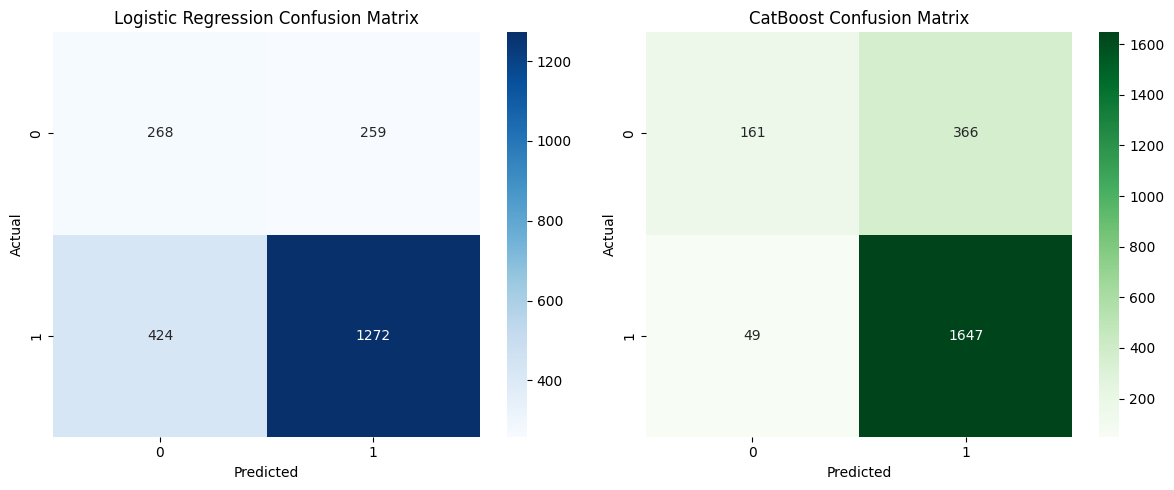

In [191]:
# Visualize confusion matrices for Logistic Regression and CatBoost on the test set.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

logistic_cm = confusion_matrix(y_test, logistic_pred)
catboost_cm = confusion_matrix(y_test, catboost_pred)

sns.heatmap(logistic_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(catboost_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('CatBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [192]:
# Print detailed classification reports for the two baseline models.
print('Logistic Regression Classification Report')
print(classification_report(y_test, logistic_pred, target_names=['bad', 'good']))

print('CatBoost Classification Report')
print(classification_report(y_test, catboost_pred, target_names=['bad', 'good']))

Logistic Regression Classification Report
              precision    recall  f1-score   support

         bad       0.39      0.51      0.44       527
        good       0.83      0.75      0.79      1696

    accuracy                           0.69      2223
   macro avg       0.61      0.63      0.61      2223
weighted avg       0.73      0.69      0.71      2223

CatBoost Classification Report
              precision    recall  f1-score   support

         bad       0.77      0.31      0.44       527
        good       0.82      0.97      0.89      1696

    accuracy                           0.81      2223
   macro avg       0.79      0.64      0.66      2223
weighted avg       0.81      0.81      0.78      2223



In [193]:
# Run a small XGBoost grid search over the requested hyperparameter combinations.
from itertools import product

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost is not installed in this environment. Run `%pip install xgboost` and rerun this cell."
    ) from exc

xgb_results = []
best_xgb_model = None
best_xgb_metrics = None
best_xgb_pred = None
best_xgb_proba = None
best_xgb_score = -np.inf

for n_estimators, learning_rate, max_depth in product([100, 200], [0.01, 0.1], [4, 6]):
    xgb_model = Pipeline(
        steps=[
            ('preprocessor', logistic_preprocessor),
            (
                'classifier',
                XGBClassifier(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    objective='binary:logistic',
                    eval_metric='logloss',
                    random_state=42,
                ),
            ),
        ]
    )

    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

    current_metrics = evaluate_binary_model('XGBoost', y_test, xgb_pred, xgb_proba)
    current_metrics['n_estimators'] = n_estimators
    current_metrics['learning_rate'] = learning_rate
    current_metrics['max_depth'] = max_depth
    xgb_results.append(current_metrics)

    if current_metrics['roc_auc'] > best_xgb_score:
        best_xgb_score = current_metrics['roc_auc']
        best_xgb_model = xgb_model
        best_xgb_metrics = current_metrics
        best_xgb_pred = xgb_pred
        best_xgb_proba = xgb_proba

xgb_results_df = pd.DataFrame(xgb_results).sort_values(by=['roc_auc', 'f1'], ascending=False)
xgb_results_df

,model,accuracy,precision,recall,f1,roc_auc,n_estimators,learning_rate,max_depth
7,XGBoost,0.829960,0.837257,0.964623,0.896438,0.754640,200,0.10,6
3,XGBoost,0.820963,0.826131,0.969340,0.892024,0.741662,100,0.10,6
6,XGBoost,0.808367,0.816550,0.965802,0.884927,0.723370,200,0.10,4
2,XGBoost,0.797121,0.804699,0.969340,0.879380,0.715673,100,0.10,4
5,XGBoost,0.793522,0.796928,0.978774,0.878539,0.711215,200,0.01,6
1,XGBoost,0.784076,0.785446,0.986439,0.874543,0.708764,100,0.01,6
4,XGBoost,0.781826,0.785210,0.982901,0.873003,0.691513,200,0.01,4
0,XGBoost,0.779577,0.781776,0.986439,0.872263,0.682667,100,0.01,4


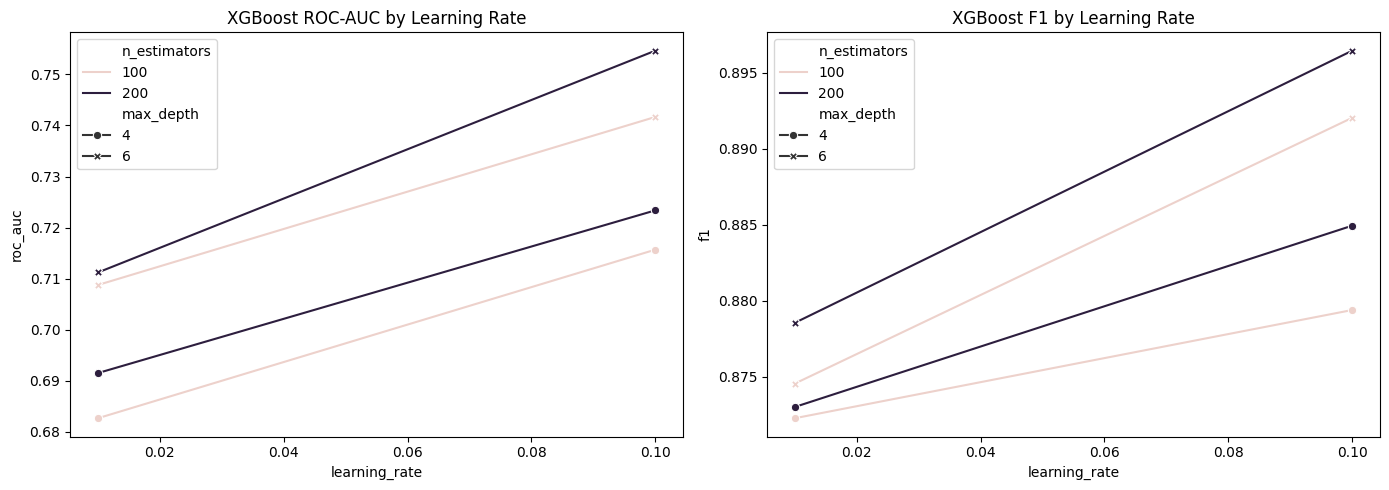

In [194]:
# Plot how learning_rate affects ROC-AUC and F1 across XGBoost configurations.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=xgb_results_df,
    x='learning_rate',
    y='roc_auc',
    hue='n_estimators',
    style='max_depth',
    markers=True,
    dashes=False,
    ax=axes[0]
)
axes[0].set_title('XGBoost ROC-AUC by Learning Rate')
axes[0].set_xlabel('learning_rate')
axes[0].set_ylabel('roc_auc')

sns.lineplot(
    data=xgb_results_df,
    x='learning_rate',
    y='f1',
    hue='n_estimators',
    style='max_depth',
    markers=True,
    dashes=False,
    ax=axes[1]
)
axes[1].set_title('XGBoost F1 by Learning Rate')
axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('f1')

plt.tight_layout()
plt.show()

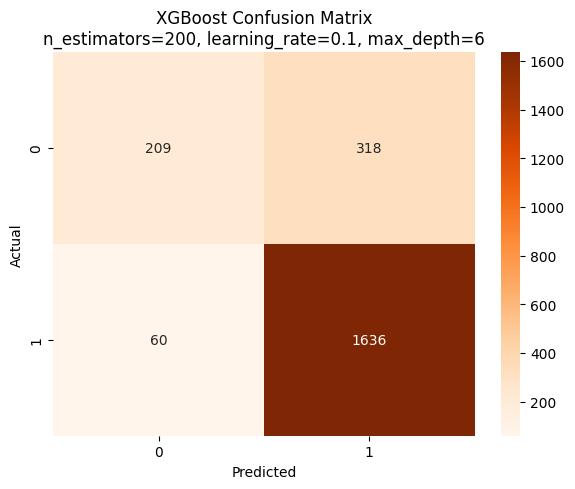

,model,accuracy,precision,recall,f1,roc_auc,n_estimators,learning_rate,max_depth
0,XGBoost,0.82996,0.837257,0.964623,0.896438,0.75464,200,0.1,6


In [195]:
# Show the confusion matrix for the best XGBoost configuration on the test set.
xgb_cm = confusion_matrix(y_test, best_xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges')
plt.title(
    f"XGBoost Confusion Matrix\n"
    f"n_estimators={best_xgb_metrics['n_estimators']}, "
    f"learning_rate={best_xgb_metrics['learning_rate']}, "
    f"max_depth={best_xgb_metrics['max_depth']}"
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

pd.DataFrame([best_xgb_metrics])

## Business-Focused Bad Review Prevention Analysis

The previous models used `good review` as the positive class. For prevention, the business question is different: we care most about detecting orders that are likely to become bad reviews.

In this section, `target_bad_review = 1` means `review_score <= 2`, and `target_bad_review = 0` means `review_score >= 3`.


In [196]:
# Create a business-focused target where the positive class is a bad review.
# This makes precision, recall, F1, and confusion matrices easier to interpret for prevention.
df_bad_review_model = df_prediction.copy()

df_bad_review_model['target_bad_review'] = (
    df_bad_review_model['review_score'] <= 2
).astype(int)

df_bad_review_model['target_label'] = df_bad_review_model['target_bad_review'].map({
    1: 'bad_review',
    0: 'good_or_neutral_review'
})

target_distribution = (
    df_bad_review_model['target_label']
    .value_counts(normalize=True)
    .rename('share')
    .to_frame()
)

target_distribution['count'] = df_bad_review_model['target_label'].value_counts()
target_distribution


,share,count
target_label,,
good_or_neutral_review,0.762959,8478
bad_review,0.237041,2634


In [197]:
# Split the features and target using the bad-review target.
# The same feature columns are reused so the results are comparable with the previous models.
X_bad = df_bad_review_model[feature_columns].copy()
y_bad = df_bad_review_model['target_bad_review'].copy()

X_bad_train, X_bad_test, y_bad_train, y_bad_test = train_test_split(
    X_bad,
    y_bad,
    test_size=0.2,
    random_state=42,
    stratify=y_bad,
)

X_bad_train.shape, X_bad_test.shape, y_bad_train.mean(), y_bad_test.mean()


((8889, 16),
 (2223, 16),
 np.float64(0.23703453706828664),
 np.float64(0.23706702654071074))

In [198]:
# Centralize metrics for the bad-review target.
# Recall is especially important here because a false negative means the model missed a likely bad review.
from sklearn.metrics import precision_recall_curve, average_precision_score


def evaluate_bad_review_model(model_name, y_true, y_pred, y_proba):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'bad_precision': precision_score(y_true, y_pred, zero_division=0),
        'bad_recall': recall_score(y_true, y_pred, zero_division=0),
        'bad_f1': f1_score(y_true, y_pred, zero_division=0),
        'bad_pr_auc': average_precision_score(y_true, y_proba),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }


In [199]:
# Train CatBoost again, now optimizing the business target: bad_review = 1.
# Class weights help the model pay more attention to the minority class.
bad_review_class_weights = {
    0: 1,
    1: (y_bad_train == 0).sum() / (y_bad_train == 1).sum()
}

catboost_bad_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='PRAUC',
    class_weights=bad_review_class_weights,
    verbose=0,
    random_seed=42,
)

catboost_bad_model.fit(
    X_bad_train,
    y_bad_train,
    cat_features=categorical_columns,
)

catboost_bad_proba = catboost_bad_model.predict_proba(X_bad_test)[:, 1]
catboost_bad_pred_default = (catboost_bad_proba >= 0.50).astype(int)

catboost_bad_default_metrics = evaluate_bad_review_model(
    'CatBoost bad-review target - default threshold',
    y_bad_test,
    catboost_bad_pred_default,
    catboost_bad_proba,
)

pd.DataFrame([catboost_bad_default_metrics])


,model,accuracy,bad_precision,bad_recall,bad_f1,bad_pr_auc,roc_auc
0,CatBoost bad-review target - default threshold,0.784076,0.542805,0.565465,0.553903,0.594167,0.762137


In [200]:
# Tune the decision threshold to catch more bad reviews.
# F2-score gives recall more weight than precision, which fits a prevention use case.
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

for threshold in thresholds:
    threshold_pred = (catboost_bad_proba >= threshold).astype(int)
    bad_precision = precision_score(y_bad_test, threshold_pred, zero_division=0)
    bad_recall = recall_score(y_bad_test, threshold_pred, zero_division=0)

    if bad_precision + bad_recall == 0:
        bad_f2 = 0
    else:
        bad_f2 = (5 * bad_precision * bad_recall) / ((4 * bad_precision) + bad_recall)

    threshold_results.append({
        'threshold': threshold,
        'bad_precision': bad_precision,
        'bad_recall': bad_recall,
        'bad_f2': bad_f2,
        'predicted_bad_share': threshold_pred.mean(),
    })

threshold_results_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results_df.sort_values('bad_f2', ascending=False).iloc[0]
best_bad_threshold = best_threshold_row['threshold']

best_threshold_row.to_frame().T


,threshold,bad_precision,bad_recall,bad_f2,predicted_bad_share
19,0.24,0.266915,0.950664,0.628607,0.844354


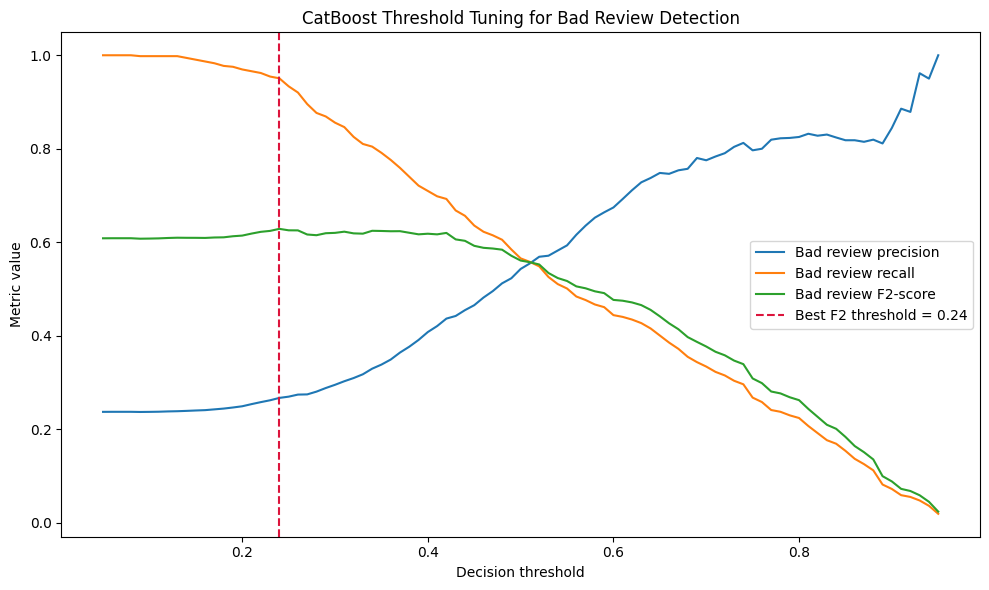

In [201]:
# Visualize the threshold trade-off.
# Lower thresholds usually detect more bad reviews, but they also create more false alerts.
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=threshold_results_df,
    x='threshold',
    y='bad_precision',
    label='Bad review precision'
)
sns.lineplot(
    data=threshold_results_df,
    x='threshold',
    y='bad_recall',
    label='Bad review recall'
)
sns.lineplot(
    data=threshold_results_df,
    x='threshold',
    y='bad_f2',
    label='Bad review F2-score'
)

plt.axvline(best_bad_threshold, color='crimson', linestyle='--', label=f'Best F2 threshold = {best_bad_threshold:.2f}')
plt.title('CatBoost Threshold Tuning for Bad Review Detection')
plt.xlabel('Decision threshold')
plt.ylabel('Metric value')
plt.legend()
plt.tight_layout()
plt.show()


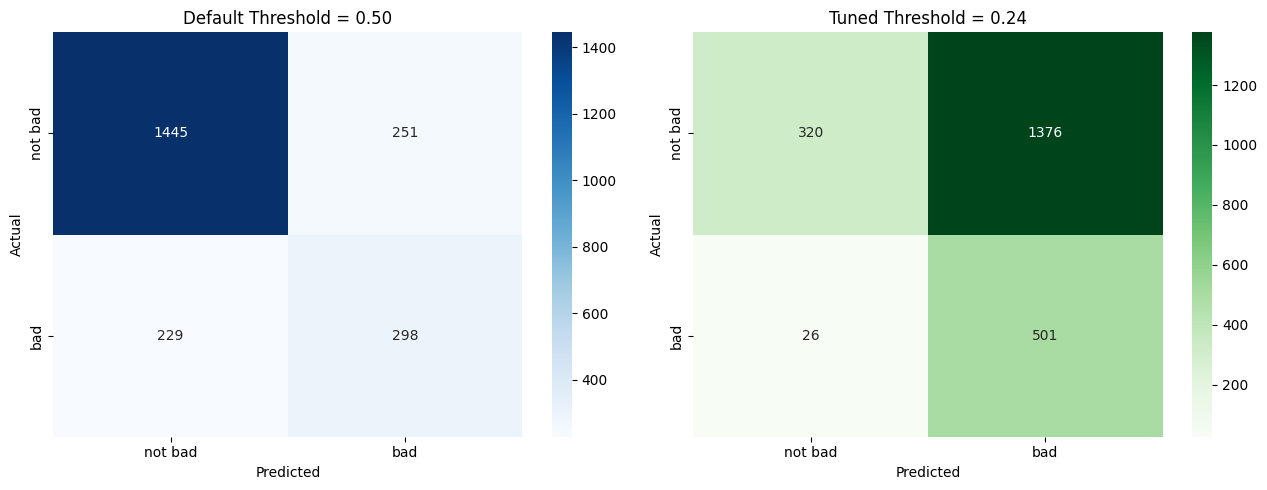

Default threshold classification report
              precision    recall  f1-score   support

     not_bad       0.86      0.85      0.86      1696
         bad       0.54      0.57      0.55       527

    accuracy                           0.78      2223
   macro avg       0.70      0.71      0.71      2223
weighted avg       0.79      0.78      0.79      2223

Tuned threshold classification report
              precision    recall  f1-score   support

     not_bad       0.92      0.19      0.31      1696
         bad       0.27      0.95      0.42       527

    accuracy                           0.37      2223
   macro avg       0.60      0.57      0.37      2223
weighted avg       0.77      0.37      0.34      2223



,model,accuracy,bad_precision,bad_recall,bad_f1,bad_pr_auc,roc_auc
0,CatBoost bad-review target - default threshold,0.784076,0.542805,0.565465,0.553903,0.594167,0.762137
1,CatBoost bad-review target - tuned threshold,0.369321,0.266915,0.950664,0.416805,0.594167,0.762137


In [202]:
# Evaluate the tuned threshold with a confusion matrix and detailed report.
# Rows are actual classes and columns are predicted classes.
catboost_bad_pred_tuned = (catboost_bad_proba >= best_bad_threshold).astype(int)

catboost_bad_tuned_metrics = evaluate_bad_review_model(
    'CatBoost bad-review target - tuned threshold',
    y_bad_test,
    catboost_bad_pred_tuned,
    catboost_bad_proba,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

default_cm = confusion_matrix(y_bad_test, catboost_bad_pred_default)
tuned_cm = confusion_matrix(y_bad_test, catboost_bad_pred_tuned)

sns.heatmap(default_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Default Threshold = 0.50')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['not bad', 'bad'])
axes[0].set_yticklabels(['not bad', 'bad'])

sns.heatmap(tuned_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Tuned Threshold = {best_bad_threshold:.2f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['not bad', 'bad'])
axes[1].set_yticklabels(['not bad', 'bad'])

plt.tight_layout()
plt.show()

print('Default threshold classification report')
print(classification_report(y_bad_test, catboost_bad_pred_default, target_names=['not_bad', 'bad']))

print('Tuned threshold classification report')
print(classification_report(y_bad_test, catboost_bad_pred_tuned, target_names=['not_bad', 'bad']))

pd.DataFrame([catboost_bad_default_metrics, catboost_bad_tuned_metrics])


In [203]:
# Run stratified cross-validation to check whether CatBoost is stable across different data splits.
# This is stronger than trusting one random train/test split.
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold_number, (train_index, validation_index) in enumerate(cv.split(X_bad, y_bad), start=1):
    X_cv_train = X_bad.iloc[train_index]
    X_cv_validation = X_bad.iloc[validation_index]
    y_cv_train = y_bad.iloc[train_index]
    y_cv_validation = y_bad.iloc[validation_index]

    fold_class_weights = {
        0: 1,
        1: (y_cv_train == 0).sum() / (y_cv_train == 1).sum()
    }

    cv_model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='PRAUC',
        class_weights=fold_class_weights,
        verbose=0,
        random_seed=42,
    )

    cv_model.fit(
        X_cv_train,
        y_cv_train,
        cat_features=categorical_columns,
    )

    cv_proba = cv_model.predict_proba(X_cv_validation)[:, 1]
    cv_pred = (cv_proba >= best_bad_threshold).astype(int)

    fold_metrics = evaluate_bad_review_model(
        f'fold_{fold_number}',
        y_cv_validation,
        cv_pred,
        cv_proba,
    )
    cv_results.append(fold_metrics)

cv_results_df = pd.DataFrame(cv_results)
cv_summary = cv_results_df.drop(columns='model').agg(['mean', 'std'])

cv_summary


,accuracy,bad_precision,bad_recall,bad_f1,bad_pr_auc,roc_auc
mean,0.312096,0.250955,0.958244,0.397737,0.579314,0.751992
std,0.008137,0.002459,0.011447,0.003584,0.021075,0.011028


In [204]:
# Run a simple temporal validation split.
# This simulates a more realistic scenario: train on older orders and test on newer orders.
temporal_model_df = df_raw_featured[
    feature_columns + ['order_purchase_timestamp', 'review_score']
].replace([np.inf, -np.inf], np.nan).dropna().copy()

temporal_model_df['target_bad_review'] = (
    temporal_model_df['review_score'] <= 2
).astype(int)

temporal_model_df = temporal_model_df.sort_values('order_purchase_timestamp').reset_index(drop=True)
split_index = int(len(temporal_model_df) * 0.80)

temporal_train_df = temporal_model_df.iloc[:split_index].copy()
temporal_test_df = temporal_model_df.iloc[split_index:].copy()

X_temporal_train = temporal_train_df[feature_columns]
y_temporal_train = temporal_train_df['target_bad_review']
X_temporal_test = temporal_test_df[feature_columns]
y_temporal_test = temporal_test_df['target_bad_review']

temporal_class_weights = {
    0: 1,
    1: (y_temporal_train == 0).sum() / (y_temporal_train == 1).sum()
}

catboost_temporal_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='PRAUC',
    class_weights=temporal_class_weights,
    verbose=0,
    random_seed=42,
)

catboost_temporal_model.fit(
    X_temporal_train,
    y_temporal_train,
    cat_features=categorical_columns,
)

temporal_proba = catboost_temporal_model.predict_proba(X_temporal_test)[:, 1]
temporal_pred = (temporal_proba >= best_bad_threshold).astype(int)

temporal_metrics = evaluate_bad_review_model(
    'CatBoost temporal validation',
    y_temporal_test,
    temporal_pred,
    temporal_proba,
)

print('Train date range:', temporal_train_df['order_purchase_timestamp'].min(), 'to', temporal_train_df['order_purchase_timestamp'].max())
print('Test date range:', temporal_test_df['order_purchase_timestamp'].min(), 'to', temporal_test_df['order_purchase_timestamp'].max())
print(classification_report(y_temporal_test, temporal_pred, target_names=['not_bad', 'bad']))

pd.DataFrame([temporal_metrics])


Train date range: 2017-05-04 19:35:21 to 2018-07-31 13:16:33
Test date range: 2018-07-31 13:18:12 to 2018-08-29 14:18:28
              precision    recall  f1-score   support

     not_bad       0.88      0.30      0.45      1748
         bad       0.25      0.84      0.38       475

    accuracy                           0.42      2223
   macro avg       0.56      0.57      0.42      2223
weighted avg       0.74      0.42      0.44      2223



,model,accuracy,bad_precision,bad_recall,bad_f1,bad_pr_auc,roc_auc
0,CatBoost temporal validation,0.418354,0.247219,0.842105,0.382226,0.445332,0.679802


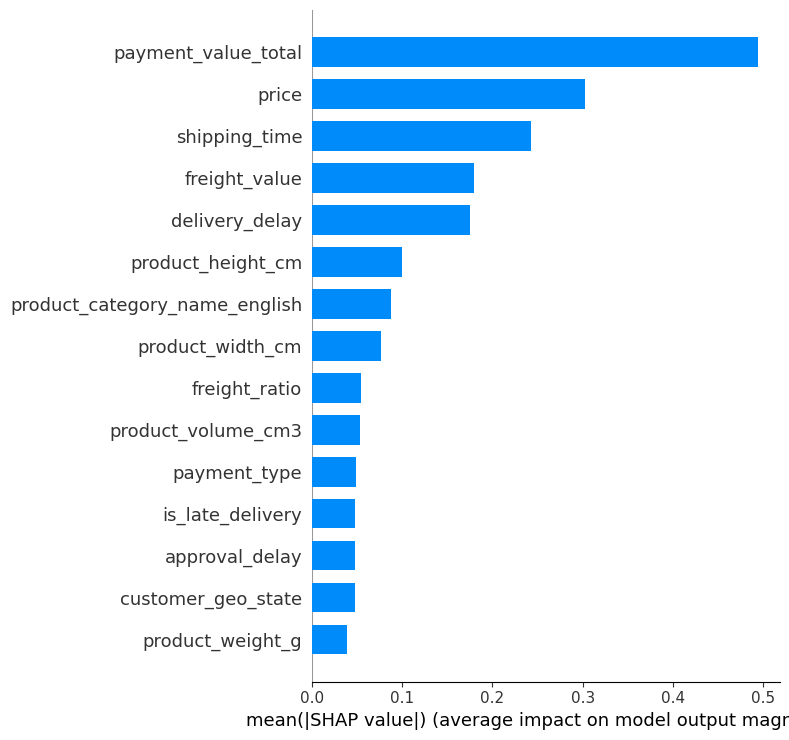

In [205]:
# Explain the CatBoost model using SHAP values when the package is available.
# SHAP estimates how much each feature contributes to pushing predictions toward bad or not bad reviews.
try:
    import shap

    shap_sample_size = min(1000, len(X_bad_test))
    shap_sample = X_bad_test.sample(shap_sample_size, random_state=42)

    explainer = shap.TreeExplainer(catboost_bad_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        plot_type='bar',
        max_display=15,
        show=True
    )

except ImportError:
    print('SHAP is not installed in this environment. Using CatBoost feature importance instead.')

    feature_importance_df = (
        pd.DataFrame({
            'feature': feature_columns,
            'importance': catboost_bad_model.get_feature_importance()
        })
        .sort_values('importance', ascending=False)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance_df.head(15),
        x='importance',
        y='feature',
        color='steelblue'
    )
    plt.title('CatBoost Feature Importance for Bad Review Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    display(feature_importance_df)


In [206]:
# Summarize the most important model drivers in a table.
# These variables should be treated as strong signals, not automatic causal proof.
catboost_bad_feature_importance = (
    pd.DataFrame({
        'feature': feature_columns,
        'importance': catboost_bad_model.get_feature_importance()
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

catboost_bad_feature_importance.head(15)


,feature,importance
0,payment_value_total,15.124560
1,delivery_delay,12.306767
2,price,9.560301
3,shipping_time,9.077317
4,freight_value,7.732808
5,product_category_name_english,6.992652
6,approval_delay,5.670841
7,product_height_cm,5.251439
8,freight_ratio,5.049841
9,product_width_cm,4.744450


In [207]:
# Compare the real behavior of key variables between bad and non-bad reviews.
# This helps connect model importance with interpretable business patterns.
df_bad_review_model['target_label_readable'] = df_bad_review_model['target_bad_review'].map({
    0: 'not_bad_review',
    1: 'bad_review'
})

key_numeric_features = [
    'payment_value_total',
    'delivery_delay',
    'shipping_time',
    'price',
    'freight_value',
    'freight_ratio',
    'product_weight_g',
    'product_volume_cm3',
    'approval_delay',
]

behavior_summary = (
    df_bad_review_model
    .groupby('target_label_readable')[key_numeric_features]
    .mean()
    .T
)

behavior_summary['bad_minus_not_bad'] = (
    behavior_summary['bad_review'] - behavior_summary['not_bad_review']
)

behavior_summary.sort_values('bad_minus_not_bad', ascending=False)


target_label_readable,bad_review,not_bad_review,bad_minus_not_bad
product_volume_cm3,15810.682232,14045.872965,1764.809267
product_weight_g,2317.310554,2036.836164,280.474390
payment_value_total,259.528174,188.564644,70.963530
price,136.250835,128.194633,8.056202
shipping_time,13.796212,9.570080,4.226131
delivery_delay,-10.359454,-12.781980,2.422526
freight_value,22.584658,21.670226,0.914432
freight_ratio,0.369087,0.318815,0.050271
approval_delay,0.499317,0.455639,0.043678


In [208]:
# Identify product categories with the highest bad-review rate.
# A minimum row count avoids overreacting to categories with only a few observations.
category_bad_review_summary = (
    df_bad_review_model
    .groupby('product_category_name_english')
    .agg(
        rows=('target_bad_review', 'size'),
        bad_review_rate=('target_bad_review', 'mean'),
        avg_review_score=('review_score', 'mean'),
    )
    .query('rows >= 100')
    .sort_values('bad_review_rate', ascending=False)
)

category_bad_review_summary.head(15)


,rows,bad_review_rate,avg_review_score
product_category_name_english,,,
office_furniture,199,0.396985,3.055276
furniture_decor,696,0.285920,3.590517
computers_accessories,672,0.278274,3.638393
bed_bath_table,1153,0.270598,3.672160
construction_tools_construction,179,0.262570,3.821229
housewares,893,0.258679,3.679731
baby,310,0.258065,3.645161
watches_gifts,900,0.252222,3.703333
telephony,426,0.234742,3.708920


### How to Read These Results

- The tuned threshold is designed to detect more bad reviews, even if that creates more false alerts.
- Cross-validation checks whether the result is stable across multiple splits.
- Temporal validation is closer to a real business setting because future orders are predicted from past orders.
- SHAP or feature importance shows which variables influence predictions the most, but it does not prove causality by itself.
- The strongest business recommendation should focus on operational levers: delivery delays, shipping time, high-value orders, freight/price pressure, and high-risk product categories.


### Business Interpretation of the Bad-Review Model

The new target changes the business question: instead of asking whether an order will receive a good review, the model now asks whether an order is at risk of becoming a bad review.

With the default threshold of `0.50`, CatBoost produced a more balanced prevention model:

- `bad_precision`: about `0.54`
- `bad_recall`: about `0.57`
- `bad_f1`: about `0.55`
- `bad_pr_auc`: about `0.59`
- `roc_auc`: about `0.76`

This means the model catches a little more than half of bad reviews while keeping false alerts at a moderate level.

After threshold tuning, the best F2 threshold was about `0.24`. This strongly increases bad-review recall:

- `bad_recall`: about `0.95`
- `bad_precision`: about `0.27`
- `bad_f2`: about `0.63`

This threshold is useful if the business prefers to catch almost every risky order, even if many normal orders are also flagged. It is not ideal if the team has limited capacity to intervene, because it flags a large share of orders.

Cross-validation showed that the high-recall strategy is stable across random splits, with average bad-review recall around `0.96`. However, temporal validation was weaker, with `roc_auc` around `0.68` and bad-review recall around `0.84`. This is important because temporal validation is closer to real business usage: training on past orders and predicting future orders.

The most influential variables in CatBoost were:

- `payment_value_total`
- `delivery_delay`
- `price`
- `shipping_time`
- `freight_value`
- `product_category_name_english`
- `approval_delay`
- product size and weight variables

The strongest practical recommendation is to use the model as a risk-ranking tool, not as an automatic decision system. Orders with long shipping times, delivery delays, high payment value, high freight pressure, large/heavy products, and high-risk categories should be prioritized for operational follow-up.

These results support business hypotheses, but they do not prove causality. To claim that an action prevents bad reviews.


In [ ]:
# Save the best overall model as a reusable artifact.
# XGBoost had the best overall performance in the model comparison.
# The saved pipeline includes preprocessing, so it can be loaded later for predictions.
from pathlib import Path
import json
import joblib

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

best_model_path = models_dir / 'best_xgboost_model.pkl'
best_model_metadata_path = models_dir / 'best_xgboost_model_metadata.json'

joblib.dump(best_xgb_model, best_model_path)

best_model_metadata = {
    'model_name': 'XGBoostClassifier',
    'target': 'target_good_review',
    'positive_class': 'good_review',
    'threshold': 0.5,
    'metrics': best_xgb_metrics,
    'feature_columns': feature_columns,
    'categorical_columns': categorical_columns,
    'numeric_columns': numeric_columns,
    'artifact_path': str(best_model_path),
    'artifact_format': 'pkl',
}

best_model_metadata_path.write_text(json.dumps(best_model_metadata, indent=2))

print(f'Saved model to: {best_model_path}')
print(f'Saved metadata to: {best_model_metadata_path}')
